In [ ]:
import torch
from torch_geometric.data import Data

/Users/tungvuduc/opt/anaconda3/envs/dlbio_arm64/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# let's do a small example
edge_index = torch.tensor([[0, 1],
                           [1, 0], 
                           [1, 2],
                           [2, 1]], dtype=torch.long)

x = torch.tensor([[-1], [0], [1]], dtype=torch.float)
data = Data(x=x, edge_index=edge_index.T)

print(data)

Data(x=[3, 1], edge_index=[2, 4])


In [3]:
print(data.num_nodes) # print number of nodes

print(data.num_edges) # print number of edges

print(data.num_node_features) # print dim of node features

print(data.has_self_loops()) # print if nodes have connections with themselves

print(data.has_isolated_nodes()) # does the data have isolated nodes?

print(data.is_directed()) # is the data directed?

3
4
1
False
False
False


In [4]:
# let's download some data from torch_geometrics
from torch_geometric.datasets import TUDataset

dataset = TUDataset(root="/tmp/ENZYMES", name="ENZYMES")
print("Dataset consists of", len(dataset), "graphs")
graph = dataset[0] # let's index the first graph
print(graph) # retrieve the first graph

print(graph.num_nodes)
print(graph.num_edges)
print(graph.num_node_features)

print(graph.is_undirected()) # is the graph undirected?
print(graph.has_self_loops()) # does the graph have nodes with connections with themselves?
print(graph.has_isolated_nodes()) # does the graph have isolated nodes?

# let's split the data in a train and test dataset
train_size = 0.8
train_split = round(len(dataset) * 0.8)

dataset = dataset.shuffle()
train_data = dataset[:train_size][0] # we can simply index the dataset object
test_data = dataset[train_size:][0]


Processing...


Dataset consists of 600 graphs
Data(edge_index=[2, 168], x=[37, 3], y=[1])
37
168
3
True
False
False


Done!


In [5]:
# let's download another dataset - this is a citation dataset
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root="/tmp/Cora", name="Cora")
graph = dataset[0]

# let's inspect the dataset
print(graph)
print(f"The dataset consists of {len(graph)} graphs")
print(f"The dataset consists of {graph.num_nodes} nodes")
print(f"The dataset consists of {graph.num_edges} edges")
print(f"The nodes in the dataset consists of {graph.num_node_features} features")
print(f"Is the data directed: {graph.is_directed()}")

print(f"The graph's train size {graph.train_mask.sum().item()}")
print(f"The graph's val size {graph.val_mask.sum().item()}")
print(f"The graph's test size {graph.test_mask.sum().item()}")

Processing...


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
The dataset consists of 6 graphs
The dataset consists of 2708 nodes
The dataset consists of 10556 edges
The nodes in the dataset consists of 1433 features
Is the data directed: False
The graph's train size 140
The graph's val size 500
The graph's test size 1000


Done!


In [6]:
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader

dataset = TUDataset(root="/tmp/ENZYMES", name="ENZYMES", use_node_attr=True).shuffle()
loader = DataLoader(dataset=dataset, batch_size=32, shuffle=True)
first_batch = [*loader][0]
print(first_batch.num_graphs) # this is the batch_size

from torch_geometric.utils import scatter
x = scatter(src=first_batch.x, index=first_batch.batch, dim=0, reduce="mean")
print(x.shape)

32
torch.Size([32, 21])


In [7]:
# let's recreate the GCNConv
import torch.nn as nn
from torch_geometric.utils import add_self_loops
from torch_geometric.utils import degree
class GCNConvScratch(nn.Module):

    def __init__(self, in_channel: int, out_channel: int):
        super().__init__()

        self.linear = nn.Linear(in_channel, out_channel, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_channel))

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):

        x = self.linear(x)
        num_nodes = x.shape[0]
        edge_index, _ = add_self_loops(edge_index, num_nodes=num_nodes)

        src, target = edge_index[0], edge_index[1]

        # normalization by 1/sqrt(deg)
        deg = degree(target, num_nodes, dtype=x.dtype)
        deg_norm = deg.pow(-0.5)
        deg_norm[deg_norm == float("inf")] = 0
        
        weights = deg_norm[src] * deg_norm[target]
        message = weights.unsqueeze(-1) * x[src]
        out = torch.zeros_like(x)
        out = out.scatter_add(dim=0, index=target.unsqueeze(-1).expand_as(message), src=message)
        
        return out + self.bias

In [ ]:
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
from torch_geometric.nn import global_mean_pool
from torch_geometric.data import Data

class GCN(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, num_classes: int, dropout: float):
        super().__init__()

        self.conv_in = GCNConv(in_channels, out_channels)
        self.conv_out = GCNConv(out_channels, out_channels)
        self.ln1 = nn.LayerNorm(out_channels)
        self.ln2 = nn.LayerNorm(out_channels)
        self.dropout = dropout

        self.classifier = nn.Linear(out_channels, num_classes)

    def forward(self, data: Data):
        x = self.conv_in(data.x, data.edge_index)
        x = self.ln1(x)
        x = F.relu(x)
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.conv_out(x, data.edge_index)
        x = self.ln2(x)
        x = F.relu(x)
        x = F.dropout(x, self.dropout, training=self.training)
        
        # pool node-level embedding into graph level-embeddings
        x = global_mean_pool(x, data.batch)
        x = self.classifier(x)
        return F.log_softmax(x, dim=-1)


In [ ]:
# let's train our simple model
epochs = 500
in_channels = dataset.num_features
out_channels = 512
batch_size = 32
num_classes = len(torch.unique(dataset.y))
train_size = round(len(dataset) * 0.7)
val_size = round(len(dataset) * 0.2)
model = GCN(in_channels, out_channels, num_classes, 0.2)
train_data = dataset[:train_size]
val_data = dataset[train_size:train_size+val_size]
test_data = dataset[train_size+val_size:]

from torch_geometric.data import Batch

train_data_all = Batch.from_data_list(train_data)
val_data_all = Batch.from_data_list(val_data)
test_data_all = Batch.from_data_list(test_data)

train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_data, batch_size=batch_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
criterion = torch.nn.NLLLoss()

train_loss_col = []
val_loss_col = []
train_accuracy_col = []
val_accuracy_col = []
for epoch in range(1, epochs + 1):
    # Training
    model.train()
    train_loss = 0
    for train_dataset in train_loader:
        optimizer.zero_grad()
        x = model(train_dataset)
        loss = criterion(x, train_dataset.y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for val_dataset in val_loader:
            x = model(val_dataset)
            loss = criterion(x, val_dataset.y)
            val_loss += loss.item()
        val_loss /= len(val_loader)

    train_accuracy = torch.mean((torch.argmax(model(train_data_all), dim=1) == train_data_all.y).float())
    val_accuracy = torch.mean((torch.argmax(model(val_data_all), dim=1) == val_data_all.y).float())
    train_accuracy_col.append(train_accuracy)
    val_accuracy_col.append(val_accuracy)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}/{epochs} | Train loss: {train_loss:.4f} | Train accuracy: {train_accuracy} | Val loss: {val_loss:.4f} | Val accuracy: {val_accuracy}")
    train_loss_col.append(train_loss)
    train_loss_col.append(train_loss)
    val_loss_col.append(val_loss)


Epoch 20/500 | Train loss: 1.6885 | Train accuracy: 0.30000001192092896 | Val loss: 1.7167 | Val accuracy: 0.2916666567325592
Epoch 40/500 | Train loss: 1.6437 | Train accuracy: 0.3571428656578064 | Val loss: 1.6882 | Val accuracy: 0.25
Epoch 60/500 | Train loss: 1.5291 | Train accuracy: 0.38333332538604736 | Val loss: 1.6221 | Val accuracy: 0.34166666865348816
Epoch 80/500 | Train loss: 1.4397 | Train accuracy: 0.4333333373069763 | Val loss: 1.6340 | Val accuracy: 0.36666667461395264
Epoch 100/500 | Train loss: 1.3397 | Train accuracy: 0.49761903285980225 | Val loss: 1.5972 | Val accuracy: 0.3583333194255829
Epoch 120/500 | Train loss: 1.2184 | Train accuracy: 0.49761903285980225 | Val loss: 1.5317 | Val accuracy: 0.36666667461395264
Epoch 140/500 | Train loss: 1.1217 | Train accuracy: 0.5404762029647827 | Val loss: 1.7195 | Val accuracy: 0.3166666626930237
Epoch 160/500 | Train loss: 0.9916 | Train accuracy: 0.6714285612106323 | Val loss: 1.5076 | Val accuracy: 0.40833333134651184
Ep

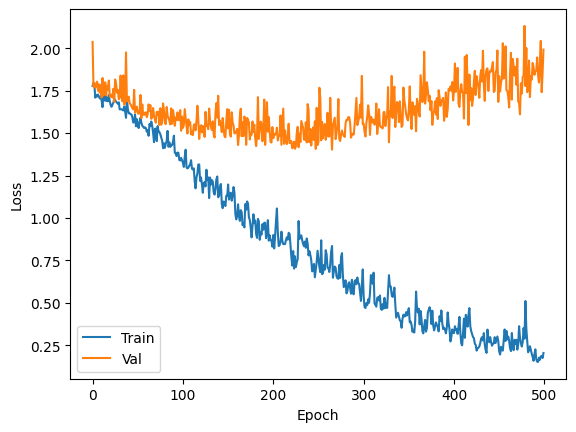

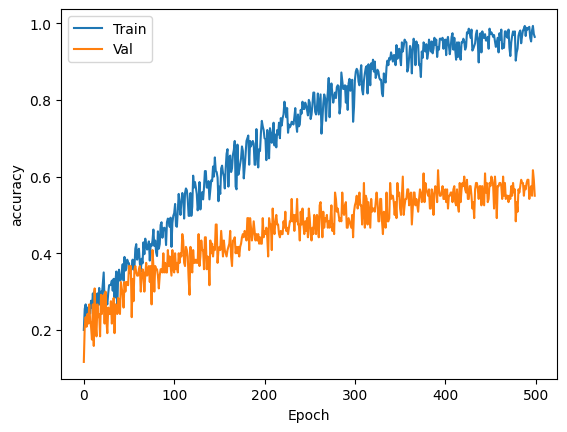

In [10]:

import matplotlib.pyplot as plt
plt.plot(train_loss_col, label="Train")
plt.plot(val_loss_col, label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(train_accuracy_col, label="Train")
plt.plot(val_accuracy_col, label="Val")
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()